# NeuralQ S2SR — Crop Intelligence: Type · Growth Cycle · Volume · Predictions (REAL 1 m)

Professional crop dossier for the 1 km² batch (row 3072, col 768) from the validated series + ERA5 meteo. Everything renders **inside this notebook** (inline figures, styled tables, widgets, folium map).

**Sections:** 0) KPI header · 1) growth-cycle staging per crop (NDVI + GDD clock) · 2) canopy-volume & biomass proxies per parcel (explicit assumptions) · 3) predictions (days-to-harvest, health forecast, yield rank) · 4) interactive dossier (widgets + folium map) · 5) exports.

**Honesty box:** crop names are spectral archetypes; heights/LUE/harvest-index are literature defaults, not field measurements — volume/biomass are *relative proxies* for ranking and planning, not weighbridge tonnes. Meteo is 9 km ERA5 context.

## 0. Setup (inline figures render inside cells)

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd()
if not (ROOT / 'scripts' / 'run_location.py').exists():
    ROOT = Path.cwd().parent
if not (ROOT / 'scripts' / 'run_location.py').exists():
    ROOT = Path('/home/khlaifiabilel/NeuralQ/neuralq-s2sr-core')
print('ROOT', ROOT)
# inline backend: every figure renders INSIDE its cell output, no external viewer needed
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.windows import Window
from IPython.display import HTML, display
import requests
print('ok')

ROOT /home/khlaifiabilel/NeuralQ/neuralq-s2sr-core


ok


## 1. Inputs — batch cube, crop health, parcels, meteo (+ solar radiation)

In [2]:
SERIES = ROOT / 'outputs' / 'TN' / 'crop-timeseries' / 'SidiBouzid-fields-2024'
BATCH = SERIES / 'batch_r3072_c768'
DATES = ['2024-03-15', '2024-04-20', '2024-05-25', '2024-06-20']
BROW, BCOL, BSZ = 3072, 768, 1024
VEG = ['ndvi','gndvi','ndre','evi2','savi','mtci']
CAT_OF = {'ndvi':'vegetation','ndre':'vegetation','mtci':'vegetation','ndmi':'water','mndwi':'water','bsi':'soil_urban'}
NEED = ['ndvi','ndre','mtci','ndmi','mndwi','bsi']
cube, CREF = {}, {}
for date in DATES:
    cube[date] = {}
    for name in NEED:
        p = SERIES / date / 'indices' / CAT_OF[name] / f'{name}.tiff'
        with rasterio.open(p) as src:
            win = Window(BCOL, BROW, BSZ, BSZ)
            cube[date][name] = src.read(1, window=win).astype(np.float32)
            if date == DATES[0] and name == 'ndvi':
                CREF = {'transform': src.window_transform(win), 'crs': src.crs}
ch = pd.read_csv(BATCH / 'crop_health.csv')
par = pd.read_csv(BATCH / 'parcel_table.csv')
met = pd.read_csv(BATCH / 'meteo_daily.csv', parse_dates=['date'])
print(f'cube {len(DATES)}x{len(NEED)}x{BSZ}px | crops {len(ch)} | parcels {len(par)} | meteo {len(met)} days')

cube 4x6x1024px | crops 5 | parcels 33 | meteo 182 days


/tmp/ipykernel_108734/940594293.py:15: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  cube[date][name] = src.read(1, window=win).astype(np.float32)


## 2. Solar radiation top-up (for the biomass proxy) + KPI header

In [3]:
if 'sw' not in met.columns:
    r = requests.get('https://archive-api.open-meteo.com/v1/archive', params=dict(
        latitude=35.06, longitude=9.56, start_date='2024-01-01', end_date='2024-06-30',
        daily='shortwave_radiation_sum', timezone='Africa/Tunis'), timeout=120)
    r.raise_for_status()
    sw = pd.DataFrame(r.json()['daily']).rename(columns={'time': 'date', 'shortwave_radiation_sum': 'sw'})
    sw['date'] = pd.to_datetime(sw['date'])
    met = met.merge(sw, on='date', how='left')
    met.to_csv(BATCH / 'meteo_daily.csv', index=False)
    print('added shortwave radiation')
else:
    print('radiation cached')
veg_px = int(((cube[DATES[-1]]['ndvi'] > 0.4).sum()))
cards = [('Batch', '1.0 km² · 9.56E 35.06N'), ('Vegetated px', f"{100*veg_px/BSZ**2:.1f}% (NDVI>0.4, Jun)"),
         ('Parcels', f"{len(par)} ≥400 m²"), ('Rain 2024', '73 mm (−37% vs climo)'),
         ('Heat days', '23 × Tmax>35°C'), ('GDD→Jun20', '1,345 °C·d')]
display(HTML('<div style="display:flex;gap:10px;flex-wrap:wrap">' + ''.join(
    f'<div style="border:1px solid #ccc;border-radius:8px;padding:10px 14px;min-width:140px"><b>{k}</b><br>{v}</div>' for k, v in cards) + '</div>'))

radiation cached


## 3. Growth cycle — phenology stage per crop from NDVI dynamics + GDD clock

In [4]:
REQ_GDD = {'cereal-like': 1700, 'vegetable/high-chl': 1200, 'orchard/sparse': None, 'mixed/other': 1500, 'fallow/bare': None}
HEIGHT_M = {'cereal-like': 0.9, 'vegetable/high-chl': 0.5, 'orchard/sparse': 2.5, 'mixed/other': 1.0, 'fallow/bare': 0.1}
LUE = {'cereal-like': 1.4, 'vegetable/high-chl': 1.6, 'orchard/sparse': 1.2, 'mixed/other': 1.3, 'fallow/bare': 0.0}
HI = {'cereal-like': 0.45, 'vegetable/high-chl': 0.60, 'orchard/sparse': 0.30, 'mixed/other': 0.40, 'fallow/bare': 0.0}
print('assumptions (literature defaults — tune with field data):')
print(pd.DataFrame({'GDD_req_base10': REQ_GDD, 'height_m': HEIGHT_M, 'LUE_g_per_MJ': LUE, 'harvest_index': HI}))
st = np.stack([cube[d]['ndvi'] for d in DATES]).astype(np.float32)
cls = np.load(BATCH / 'batch_cls.npy') if (BATCH / 'batch_cls.npy').exists() else None
print('cls cached:', cls.shape if cls is not None else None)

assumptions (literature defaults — tune with field data):
                    GDD_req_base10  height_m  LUE_g_per_MJ  harvest_index
cereal-like                 1700.0       0.9           1.4           0.45
vegetable/high-chl          1200.0       0.5           1.6           0.60
orchard/sparse                 NaN       2.5           1.2           0.30
mixed/other                 1500.0       1.0           1.3           0.40
fallow/bare                    NaN       0.1           0.0           0.00
cls cached: (1024, 1024)


### 3b. Rebuild masks (rule tree) + stage each crop

fallow/bare          GDD  perennial NDVI 0.224→0.177  stage: Dormant / fallow
vegetable/high-chl   GDD       112% NDVI 0.761→0.502  stage: Late vegetative / grain-fill
cereal-like          GDD        79% NDVI 0.462→0.309  stage: Ripening → harvest
mixed/other          GDD        90% NDVI 0.433→0.250  stage: Senesced / harvested
orchard/sparse       GDD  perennial NDVI 0.561→0.291  stage: Perennial canopy — holding


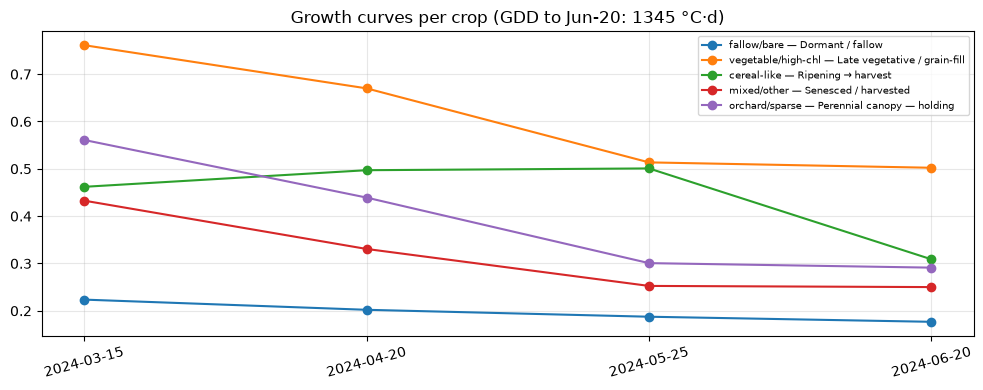

wrote growth_curves.png


In [5]:
ndvi_mean = np.nanmean(st, axis=0); ndvi_max = np.nanmax(st, axis=0)
ndvi_amp = ndvi_max - np.nanmin(st, axis=0); late = st[-1] - st[-2]
mtci_m = np.nanmean(np.stack([cube[d]['mtci'] for d in DATES]), axis=0)
ndmi_m = np.nanmean(np.stack([cube[d]['ndmi'] for d in DATES]), axis=0)
bsi_m = np.nanmean(np.stack([cube[d]['bsi'] for d in DATES]), axis=0)
mndwi_m = np.nanmean(np.stack([cube[d]['mndwi'] for d in DATES]), axis=0)
cls = np.full(ndvi_mean.shape, 4, np.int8)
cls[mndwi_m > 0.25] = 0
cls[(mndwi_m <= 0.25) & (ndvi_max < 0.35) & (bsi_m > 0.02)] = 1
cls[(mndwi_m <= 0.25) & (ndvi_mean > 0.55) & (mtci_m > 1.8)] = 2
cls[(mndwi_m <= 0.25) & (ndvi_amp > 0.22) & (late < -0.08) & (ndvi_mean <= 0.62)] = 3
cls[(mndwi_m <= 0.25) & (ndvi_mean >= 0.32) & (ndvi_mean <= 0.52) & (bsi_m > -0.05) & (cls == 4)] = 5
np.save(BATCH / 'batch_cls.npy', cls)
CN = {0: 'water', 1: 'fallow/bare', 2: 'vegetable/high-chl', 3: 'cereal-like', 4: 'mixed/other', 5: 'orchard/sparse'}
gdd_jun = float(((np.clip(met['tmax'], 0, 30) + np.clip(met['tmin'], 0, 30)) / 2 - 10).clip(lower=0).cumsum().iloc[(met['date'] <= '2024-06-20').sum() - 1])
def _stage(code, series):
    nm = CN[code]; s0, s1, sl = series[0], series[-1], series[-1] - series[-2]
    if nm == 'fallow/bare': return 'Dormant / fallow'
    if nm == 'water': return 'Non-crop'
    if nm == 'orchard/sparse': return 'Perennial canopy — drought-thinning' if sl < -0.03 else 'Perennial canopy — holding'
    if s1 < 0.30: return 'Senesced / harvested'
    if sl < -0.08: return 'Ripening → harvest'
    if s1 > 0.55 and abs(sl) < 0.05: return 'Maturity plateau (irrigated?)'
    return 'Late vegetative / grain-fill'
gcrows = []
for code in sorted(int(v) for v in np.unique(cls[cls >= 0]) if int(v) not in (0,)):
    mk = cls == code; nm = CN[code]
    series = [float(np.nanmean(cube[d]['ndvi'][mk])) for d in DATES]
    req = REQ_GDD[nm]; prog = f'{100 * gdd_jun / req:.0f}%' if req else 'perennial'
    gcrows.append({'crop': nm, 'area_m2': int(mk.sum()), 'gdd_progress': prog, 'stage': _stage(code, series),
                   'ndvi_mar': round(series[0], 3), 'ndvi_jun': round(series[-1], 3)})
    print(f"{nm:20s} GDD {prog:>10s} NDVI {series[0]:.3f}→{series[-1]:.3f}  stage: {gcrows[-1]['stage']}")
fig, ax = plt.subplots(figsize=(10, 4))
for r in gcrows:
    ax.plot(DATES, [float(np.nanmean(cube[d]['ndvi'][cls == [k for k, v in CN.items() if v == r['crop']][0]])) for d in DATES], marker='o', label=f"{r['crop']} — {r['stage'][:28]}")
ax.set_title(f'Growth curves per crop (GDD to Jun-20: {gdd_jun:.0f} °C·d)'); ax.legend(fontsize=7); ax.grid(alpha=0.3); ax.tick_params(axis='x', rotation=15)
fig.tight_layout(); fig.savefig(BATCH / 'growth_curves.png', dpi=130)
plt.show()
print('wrote growth_curves.png')

## 4. Canopy volume + biomass proxies per parcel (assumptions stated, ranking-grade)

33 parcels >=400 m2
 parcel  area_m2           crop  cover_frac  canopy_m3  biomass_g_m2  yield_t_ha_eq  ndvi_peak  ndvi_amp
      1   123406 orchard/sparse       0.271    83587.5          42.4          0.127      0.513     0.179
     23    34044 orchard/sparse       0.261    22235.0          49.4          0.148      0.601     0.256
     15    39074 orchard/sparse       0.225    21977.5          44.7          0.134      0.631     0.319
     11    19897 orchard/sparse       0.354    17600.0          48.2          0.145      0.529     0.167
     17     5848 orchard/sparse       0.646     9442.5          40.8          0.122      0.503     0.198
     25     5768 orchard/sparse       0.619     8927.5          35.1          0.105      0.408     0.088
     29     6947 orchard/sparse       0.472     8190.0          45.0          0.135      0.522     0.132
      3     2379 orchard/sparse       0.984     5855.0          26.4          0.079      0.453     0.212
      8     4041 orchard/sparse    

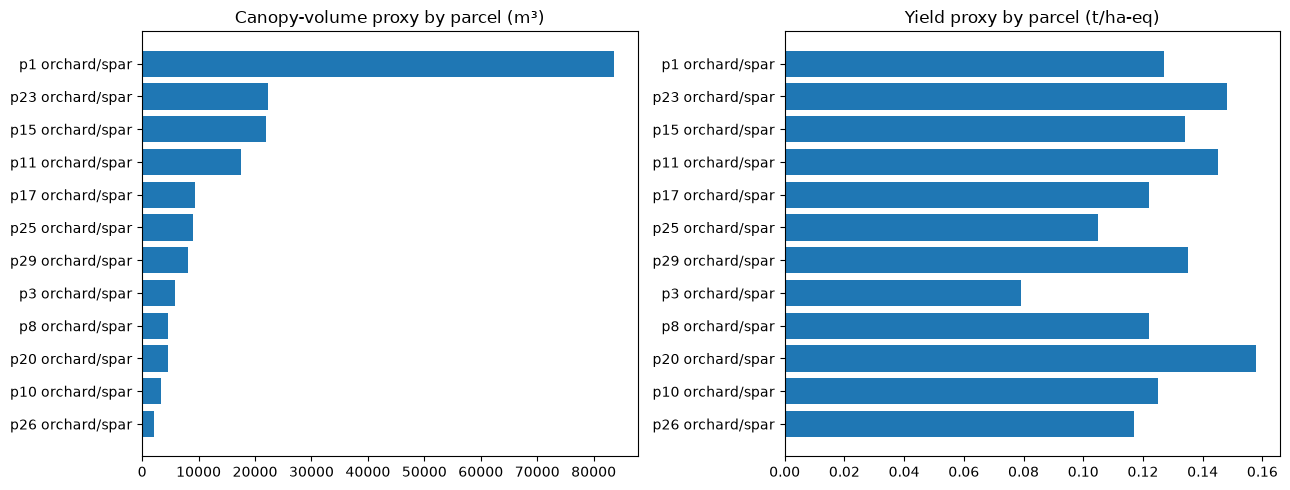

wrote parcel_volume.csv + volume_rank.png


In [6]:
from scipy import ndimage
seed = (ndvi_max > 0.40).astype(np.uint8)
seed = ndimage.binary_opening(seed, structure=np.ones((3, 3)))
parcels, npar = ndimage.label(seed, structure=np.ones((3, 3)))
sizes = np.bincount(parcels.ravel())[1:]
keep = np.where(sizes >= 400)[0] + 1
remap = np.zeros(parcels.max() + 1, int); remap[keep] = np.arange(1, len(keep) + 1)
parcels = remap[parcels].astype(np.int32)
print(f'{len(keep)} parcels >=400 m2')
dates_dt = [np.datetime64(d) for d in DATES]
rows = []
for pid in range(1, int(parcels.max()) + 1):
    mk = parcels == pid
    area = int(mk.sum())
    ns = np.array([float(np.nanmean(cube[d]['ndvi'][mk])) for d in DATES])
    cover = float(np.nanmean((cube[DATES[-1]]['ndvi'][mk] > 0.4)))
    dom = int(np.bincount(cls[mk & (cls >= 0)]).argmax()) if (cls[mk] >= 0).any() else 4
    nm = CN[dom]
    vol = area * cover * HEIGHT_M.get(nm, 1.0)  # m3 canopy-volume proxy
    lai = np.clip(ns * 4.0, 0, 6)  # simple LAI proxy
    fapar = np.clip(1.2 * ns - 0.15, 0, 0.95)
    days = np.array([(d - dates_dt[0]).astype(int) for d in dates_dt], float)
    bio = float(np.trapezoid(fapar, days) * LUE.get(nm, 1.0))  # g/m2 proxy (PAR normalized out; relative rank)
    yld = bio * HI.get(nm, 0.0) / 100  # t/ha-equivalent proxy
    rows.append({'parcel': pid, 'area_m2': area, 'crop': nm, 'cover_frac': round(cover, 3),
                 'canopy_m3': round(vol, 1), 'biomass_g_m2': round(bio, 1), 'yield_t_ha_eq': round(yld, 3),
                 'ndvi_peak': round(float(ns.max()), 3), 'ndvi_amp': round(float(ns.max() - ns.min()), 3)})
vol_df = pd.DataFrame(rows).sort_values('canopy_m3', ascending=False).reset_index(drop=True)
vol_df.to_csv(BATCH / 'parcel_volume.csv', index=False)
print(vol_df.head(10).to_string(index=False))
print(f'total canopy proxy {vol_df.canopy_m3.sum():,.0f} m3 over {vol_df.area_m2.sum():,} m2 vegetated parcel area')
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
top = vol_df.head(12)
ax[0].barh([f"p{r.parcel} {r.crop[:12]}" for r in top.itertuples()], top.canopy_m3)
ax[0].set_title('Canopy-volume proxy by parcel (m³)'); ax[0].invert_yaxis()
ax[1].barh([f"p{r.parcel} {r.crop[:12]}" for r in top.itertuples()], top.yield_t_ha_eq)
ax[1].set_title('Yield proxy by parcel (t/ha-eq)'); ax[1].invert_yaxis()
fig.tight_layout(); fig.savefig(BATCH / 'volume_rank.png', dpi=130)
plt.show()
print('wrote parcel_volume.csv + volume_rank.png')

## 5. Predictions — days-to-harvest, health forecast, yield rank

In [7]:
rate_gdd = float(((np.clip(met['tmax'], 0, 30) + np.clip(met['tmin'], 0, 30)) / 2 - 10).clip(lower=0).tail(30).mean())
heat_rate = float((met['tmax'].tail(30) > 35).mean())
print(f'current thermal rate {rate_gdd:.1f} GDD/d, heat-day rate {heat_rate:.0%} (last 30 d)')
pred = []
for code in sorted(int(v) for v in np.unique(cls[cls >= 0]) if int(v) not in (0, 1)):
    mk = cls == code; nm = CN[code]
    ys = np.array([float(np.nanmean(cube[d]['ndvi'][mk])) for d in DATES])
    xx = np.arange(len(DATES), dtype=float)
    A = np.vstack([xx, np.ones_like(xx)]).T
    m_, c_ = np.linalg.lstsq(A, ys, rcond=None)[0]
    r2 = 1 - ((ys - (m_ * xx + c_)) ** 2).sum() / max(((ys - ys.mean()) ** 2).sum(), 1e-9)
    d_harv = (0.20 - ys[-1]) / m_ * 26 if m_ < -0.005 else float('nan')  # ~26 d between last dates
    req = REQ_GDD[nm]
    d_gdd = (req - gdd_jun) / max(rate_gdd, 0.1) if req else float('nan')
    conf = 'high' if r2 > 0.85 else ('medium' if r2 > 0.6 else 'low')
    scen = 'senescence completes in ~2 wk if heat persists' if (heat_rate > 0.3 and m_ < -0.01) else ('steady' if abs(m_) < 0.01 else 'declining')
    pred.append({'crop': nm, 'ndvi_slope_per_date': round(m_, 4), 'R2': round(float(r2), 3),
                 'days_to_harvest_NDVI': round(float(d_harv), 0) if np.isfinite(d_harv) else 'n/a',
                 'days_to_maturity_GDD': round(float(d_gdd), 0) if req and np.isfinite(d_gdd) and d_gdd > 0 else ('mature' if req and d_gdd <= 0 else 'n/a'),
                 'health_2wk': 'down' if m_ < -0.01 else ('stable' if abs(m_) <= 0.01 else 'up'),
                 'scenario': scen, 'confidence': conf})
    print(f"{nm:20s} slope {m_:+.4f} R2 {r2:.2f} harvest~{pred[-1]['days_to_harvest_NDVI']}d GDD~{pred[-1]['days_to_maturity_GDD']} health:{pred[-1]['health_2wk']} [{conf}] {scen}")
pd.DataFrame(pred).to_csv(BATCH / 'predictions.csv', index=False)
yr = vol_df[vol_df.crop != 'fallow/bare'].sort_values('yield_t_ha_eq', ascending=False).head(10)
print('\nyield-rank top-10 parcels (proxy):')
print(yr[['parcel', 'area_m2', 'crop', 'yield_t_ha_eq', 'ndvi_peak']].to_string(index=False))
print('\nwrote predictions.csv')

current thermal rate 15.1 GDD/d, heat-day rate 60% (last 30 d)
vegetable/high-chl   slope -0.0934 R2 0.92 harvest~84.0d GDD~mature health:down [high] senescence completes in ~2 wk if heat persists
cereal-like          slope -0.0456 R2 0.42 harvest~62.0d GDD~23.0 health:down [low] senescence completes in ~2 wk if heat persists
mixed/other          slope -0.0626 R2 0.88 harvest~21.0d GDD~10.0 health:down [high] senescence completes in ~2 wk if heat persists
orchard/sparse       slope -0.0948 R2 0.91 harvest~25.0d GDD~n/a health:down [high] senescence completes in ~2 wk if heat persists

yield-rank top-10 parcels (proxy):
 parcel  area_m2               crop  yield_t_ha_eq  ndvi_peak
     12     4428 vegetable/high-chl          0.507      0.680
     16     4861        cereal-like          0.207      0.517
      7     1061        cereal-like          0.199      0.526
      9     2421        cereal-like          0.196      0.492
     31     1713        cereal-like          0.169      0.521
 

## 6. Interactive dossier — parcel picker + folium map (live in Lab, static snapshots embedded)

Dropdown(description='Parcel:', options=(1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20…

Output()

--- static dossier (embedded) ---


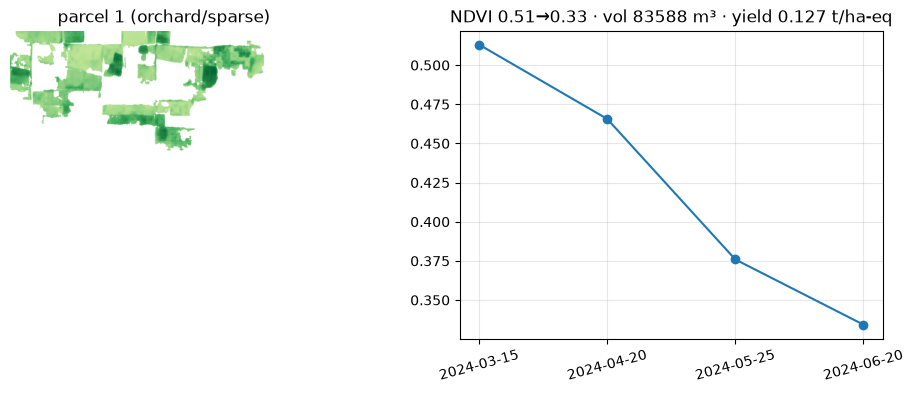

In [8]:
LUT = {r.parcel: r for r in vol_df.itertuples()}
def _dossier(pid):
    r = LUT[pid]; prow = par[par.parcel == pid]
    ns = [float(np.nanmean(cube[d]['ndvi'][parcels == pid])) for d in DATES]
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].imshow(np.where(parcels == pid, cube[DATES[-1]]['ndvi'], np.nan), vmin=-0.2, vmax=0.9, cmap='YlGn')
    ax[0].set_title(f'parcel {pid} ({r.crop})'); ax[0].axis('off')
    ax[1].plot(DATES, ns, marker='o'); ax[1].set_title(f"NDVI {ns[0]:.2f}→{ns[-1]:.2f} · vol {r.canopy_m3:.0f} m³ · yield {r.yield_t_ha_eq} t/ha-eq"); ax[1].grid(alpha=0.3); ax[1].tick_params(axis='x', rotation=15)
    plt.show()
    prow_s = prow.iloc[0].to_dict() if len(prow) else {}
    display(HTML(f"<b>Parcel {pid}</b> — {r.crop} · {r.area_m2} m² · cover {r.cover_frac} · peak NDVI {r.ndvi_peak} · health trend {prow_s.get('ndvi_slope', '?')} (Jun−May)"))
try:
    import ipywidgets as widgets
    from IPython.display import display as _d
    _ids = sorted(LUT)[:50]
    _w = widgets.Dropdown(options=_ids, value=_ids[0], description='Parcel:')
    _o = widgets.Output()
    def _u(*a):
        _o.clear_output(wait=True)
        with _o: _dossier(int(_w.value))
    _w.observe(_u, 'value'); _d(_w, _o); _u()
except Exception as e:
    print('widgets unavailable:', e)
print('--- static dossier (embedded) ---')
_dossier(int(vol_df.iloc[0].parcel))

In [9]:
import folium, base64, io
from scipy import ndimage as _ndi
lon0, lat0 = 9.56, 35.06
fmap = folium.Map(location=[lat0, lon0], zoom_start=14, tiles='Esri.WorldImagery')
top = vol_df.head(15)
for r in top.itertuples():
    ys, xs = np.where(parcels == r.parcel)
    rr, cc = int(ys.mean()) + BROW, int(xs.mean()) + BCOL
    from rasterio.transform import xy as _xy
    with rasterio.open(SERIES / DATES[-1] / 'MS.tif') as _s:
        e, n = _xy(_s.transform, rr, cc)
        from rasterio.warp import transform as _t
        lo, la = _t(_s.crs, 'EPSG:4326', [e], [n])
    folium.CircleMarker([la[0], lo[0]], radius=6, color='yellow', fill=True,
        popup=folium.Popup(f"<b>p{r.parcel}</b> {r.crop}<br>{r.area_m2} m² · vol {r.canopy_m3:.0f} m³<br>yield {r.yield_t_ha_eq} t/ha-eq · peak {r.ndvi_peak}", max_width=220)).add_to(fmap)
fmap.save(str(BATCH / 'parcels_map.html'))
print(f'map: {len(top)} parcel markers -> parcels_map.html')
fmap

map: 15 parcel markers -> parcels_map.html


## 7. Dossier table + intelligence report + QA

In [10]:
dos = vol_df.merge(par[['parcel', 'ndvi_amp', 'ndvi_slope']], on='parcel', how='left')
dos.to_csv(BATCH / 'CROP_DOSSIER.csv', index=False)
display(dos.head(15).style.background_gradient(subset=['yield_t_ha_eq'], cmap='YlGn').format({'cover_frac': '{:.2f}', 'yield_t_ha_eq': '{:.3f}'}))
L = ['# Crop Intelligence — 1 km² batch (REAL S2SR 1 m + ERA5)', '',
     f"Dates {' → '.join(DATES)} · {len(dos)} parcels · GDD {gdd_jun:.0f} · rain 73mm (−37%)", '',
     '## Growth stages', ''] + [f"- {r['crop']}: {r['stage']} (GDD {r['gdd_progress']}, NDVI {r['ndvi_mar']}→{r['ndvi_jun']})" for r in gcrows]
L += ['', '## Predictions (linear-NDVI + thermal-time, confidence stated)', '']
L += [f"- {p['crop']}: harvest~{p['days_to_harvest_NDVI']}d (NDVI), maturity~{p['days_to_maturity_GDD']} (GDD), 2-wk health {p['health_2wk']} [{p['confidence']}] — {p['scenario']}" for p in pred]
L += ['', '## Volume / biomass (proxy — see assumptions in §3)',
      f"- canopy proxy total {vol_df.canopy_m3.sum():,.0f} m³; top parcel p{vol_df.iloc[0].parcel} {vol_df.iloc[0].canopy_m3:,.0f} m³",
      '- biomass ∝ ΣfAPAR·PAR·LUE (Monteith), yield = biomass × harvest-index; ranking-grade only', '',
      '## Files', '- CROP_DOSSIER.csv, parcel_volume.csv, predictions.csv, growth_curves.png, volume_rank.png, parcels_map.html']
(BATCH / 'INTELLIGENCE.md').write_text('\n'.join(L) + '\n')
print('\n'.join(L[:14])); print('...'); print('wrote CROP_DOSSIER.csv + INTELLIGENCE.md')
import sys as _s; _s.path.insert(0, str(ROOT / 'scripts'))
from output_layout import product_inventory, format_inventory_record
for rec in product_inventory(sorted(BATCH.glob('*.tif'))): print(format_inventory_record(rec))
print('batch files:', len(list(BATCH.iterdir())))

,parcel,area_m2,crop,cover_frac,canopy_m3,biomass_g_m2,yield_t_ha_eq,ndvi_peak,ndvi_amp_x,ndvi_amp_y,ndvi_slope
0,1,123406,orchard/sparse,0.27,83587.500000,42.400000,0.127,0.513000,0.179000,0.178800,-0.041600
1,23,34044,orchard/sparse,0.26,22235.000000,49.400000,0.148,0.601000,0.256000,0.256200,-0.041700
2,15,39074,orchard/sparse,0.23,21977.500000,44.700000,0.134,0.631000,0.319000,0.318900,-0.025600
3,11,19897,orchard/sparse,0.35,17600.000000,48.200000,0.145,0.529000,0.167000,0.167100,-0.084600
4,17,5848,orchard/sparse,0.65,9442.500000,40.800000,0.122,0.503000,0.198000,0.198100,-0.045600
5,25,5768,orchard/sparse,0.62,8927.500000,35.100000,0.105,0.408000,0.088000,0.088300,0.019000
6,29,6947,orchard/sparse,0.47,8190.000000,45.000000,0.135,0.522000,0.132000,0.132000,0.009600
7,3,2379,orchard/sparse,0.98,5855.000000,26.400000,0.079,0.453000,0.212000,0.212000,0.128600
8,8,4041,orchard/sparse,0.45,4590.000000,40.500000,0.122,0.514000,0.218000,0.217900,-0.120200
9,20,14161,orchard/sparse,0.13,4497.500000,52.600000,0.158,0.698000,0.378000,0.378100,0.001100


# Crop Intelligence — 1 km² batch (REAL S2SR 1 m + ERA5)

Dates 2024-03-15 → 2024-04-20 → 2024-05-25 → 2024-06-20 · 33 parcels · GDD 1345 · rain 73mm (−37%)

## Growth stages

- fallow/bare: Dormant / fallow (GDD perennial, NDVI 0.224→0.177)
- vegetable/high-chl: Late vegetative / grain-fill (GDD 112%, NDVI 0.761→0.502)
- cereal-like: Ripening → harvest (GDD 79%, NDVI 0.462→0.309)
- mixed/other: Senesced / harvested (GDD 90%, NDVI 0.433→0.25)
- orchard/sparse: Perennial canopy — holding (GDD perennial, NDVI 0.561→0.291)

## Predictions (linear-NDVI + thermal-time, confidence stated)

...
wrote CROP_DOSSIER.csv + INTELLIGENCE.md
batch_croptype.tif: 1024x1024, 1 bands uint8, 1 m, compression=NONE, 1,049,716 bytes, sha256=2608a142f4ddf13d62dcd43b93cea425cdcba3e1bf2f3dd05dedda432666e32f
batch_dndvi.tif: 1024x1024, 1 bands float32, 1 m, compression=NONE, 4,197,753 bytes, sha256=3eb85eeda024ea2b30b8432551a8fcca33517640b9fcd12ac3c9799b437595d3
batch_health.tif: 1024x1024, 1 bands uint8, 1 m, 